Customet Sentiment Analysis

In [ ]:
import pandas as pd 
import numpy as np 
import re 

from textblob import TextBlob

import matplotlib.pyplot as plt


In [3]:
from sklearn.metrics import ( 
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
# Load the dataset
df = pd.read_csv("TestReviews.csv")
df.head()

,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


In [5]:
df.shape

(4321, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  4321 non-null   str  
 1   class   4321 non-null   int64
dtypes: int64(1), str(1)
memory usage: 2.9 MB


EDA

In [7]:
df["class"].value_counts()

class
1    2989
0    1332
Name: count, dtype: int64

In [8]:
df.isnull().sum()

review    0
class     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(173)

In [10]:
df = df.drop_duplicates()

In [ ]:
# Understanding the text
df["review"].iloc[0]

"Fantastic spot for an even or a quite cocktail.  They were swell to host the Yelp crew with a great drink menu and super attentive staff.I'd certainly recommend anything with the purred fruit in it (apple, any of them really)!\n"

In [12]:
# Review length
df["review_length"] = df["review"].astype(str).apply(len)
df[["review", "review_length"]].head()

,review,review_length
0,Fantastic spot for an even or a quite cocktail...,227
1,"Love, love, love the calamari. It's so good an...",286
2,"Love this place. Stiff martinis and cocktails,...",359
3,It's everything a great cocktail bar should be...,352
4,"I came here before a pirates game, so it was a...",771


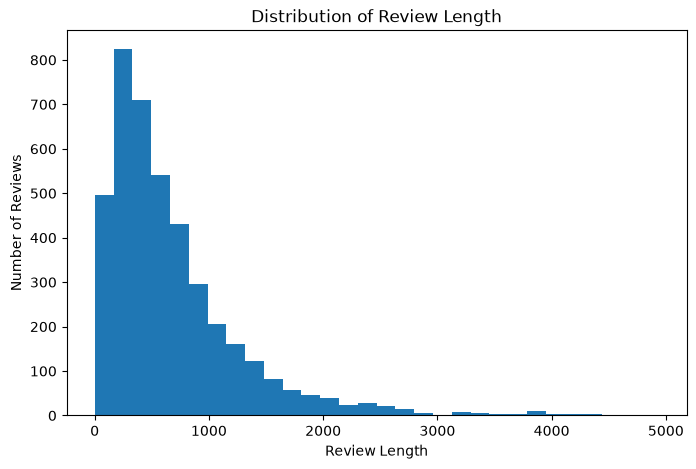

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins = 30)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")

plt.show()

In [15]:
# Text Preporcessing
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [16]:
df["clean_review"] = df["review"].apply(clean_text)

In [17]:
df[["review", "clean_review"]].head()

,review,clean_review
0,Fantastic spot for an even or a quite cocktail...,fantastic spot for an even or a quite cocktail...
1,"Love, love, love the calamari. It's so good an...",love love love the calamari its so good and sp...
2,"Love this place. Stiff martinis and cocktails,...",love this place stiff martinis and cocktails c...
3,It's everything a great cocktail bar should be...,its everything a great cocktail bar should be ...
4,"I came here before a pirates game, so it was a...",i came here before a pirates game so it was ar...


In [18]:
# TextBlob Sentiment Analysis

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity

    if polarity > 0.05:
        return "Positive"

    elif polarity < -0.05:
        return "Negative"

    else:
        return "Neutral"

In [19]:
df["sentiment"] = df["clean_review"].apply(get_sentiment)

In [20]:
df[[
    "review",
    "sentiment"
]].head(10)

,review,sentiment
0,Fantastic spot for an even or a quite cocktail...,Positive
1,"Love, love, love the calamari. It's so good an...",Positive
2,"Love this place. Stiff martinis and cocktails,...",Positive
3,It's everything a great cocktail bar should be...,Positive
4,"I came here before a pirates game, so it was a...",Positive
5,Olive or Twist is the historic site of my VERY...,Positive
6,"A beautiful little bar with an exciting ""marti...",Positive
7,My favorite bar in town love the live music an...,Positive
8,"The location is in a strip mall, but this plac...",Positive
9,THIS PLACE IS OPEN!The best food and the best ...,Positive


In [21]:
# Polarity Score
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

In [22]:
df["polarity"] = df["clean_review"].apply(get_polarity)

In [23]:
# check
df[["review", "sentiment", "polarity"]].head(10)

,review,sentiment,polarity
0,Fantastic spot for an even or a quite cocktail...,Positive,0.391270
1,"Love, love, love the calamari. It's so good an...",Positive,0.393182
2,"Love this place. Stiff martinis and cocktails,...",Positive,0.309059
3,It's everything a great cocktail bar should be...,Positive,0.296733
4,"I came here before a pirates game, so it was a...",Positive,0.267593
5,Olive or Twist is the historic site of my VERY...,Positive,0.333212
6,"A beautiful little bar with an exciting ""marti...",Positive,0.240625
7,My favorite bar in town love the live music an...,Positive,0.378788
8,"The location is in a strip mall, but this plac...",Positive,0.187554
9,THIS PLACE IS OPEN!The best food and the best ...,Positive,0.800000


In [24]:
# Sentiment Distribution
df["sentiment"].value_counts()

sentiment
Positive    3157
Neutral      498
Negative     493
Name: count, dtype: int64

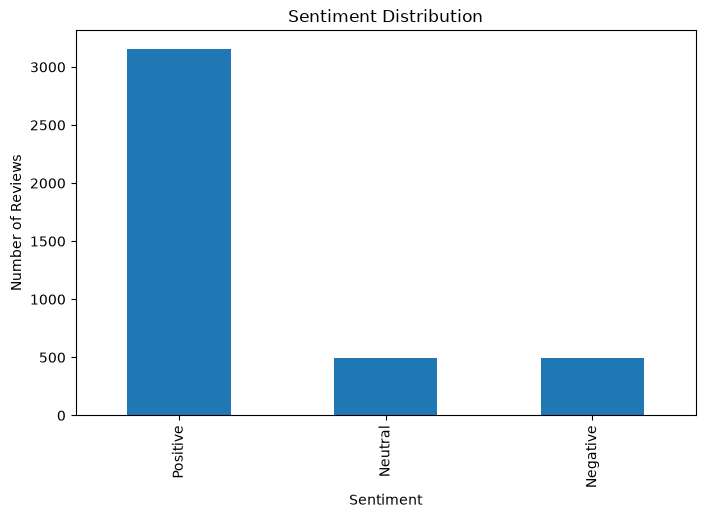

In [25]:
df["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [26]:
# convert stextblob result into numbers
df["predicted_class"] = df["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

In [27]:
df.head()

,review,class,review_length,clean_review,sentiment,polarity,predicted_class
0,Fantastic spot for an even or a quite cocktail...,1,227,fantastic spot for an even or a quite cocktail...,Positive,0.391270,1.0
1,"Love, love, love the calamari. It's so good an...",1,286,love love love the calamari its so good and sp...,Positive,0.393182,1.0
2,"Love this place. Stiff martinis and cocktails,...",1,359,love this place stiff martinis and cocktails c...,Positive,0.309059,1.0
3,It's everything a great cocktail bar should be...,1,352,its everything a great cocktail bar should be ...,Positive,0.296733,1.0
4,"I came here before a pirates game, so it was a...",1,771,i came here before a pirates game so it was ar...,Positive,0.267593,1.0


In [28]:
# remove neutral reviews for evaluation
evaluation_df = df[
    df["predicted_class"].notna()
].copy()


In [29]:
y_true = evaluation_df["class"]

y_pred = evaluation_df["predicted_class"]

In [31]:
# Accuracy
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.21%


In [32]:
# Classification Report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.51      0.67       904
           1       0.86      0.99      0.92      2746

    accuracy                           0.87      3650
   macro avg       0.90      0.75      0.79      3650
weighted avg       0.88      0.87      0.86      3650



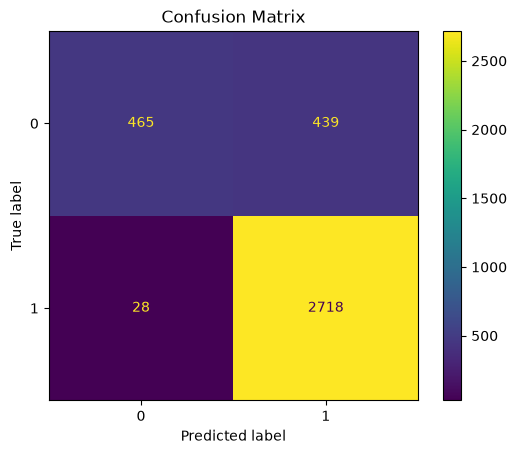

In [33]:
# COnfusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()


In [34]:
# most positive and most negative reviews
# positive
most_positive = df.loc[
    df["polarity"].idxmax()
]

print(most_positive["review"])
print(most_positive["polarity"])

try the wings, ask for honey bbq! they are the best

1.0


In [35]:
# negative reviews
most_negative = df.loc[
    df["polarity"].idxmin()
]

print(most_negative["review"])
print(most_negative["polarity"])

Horrible customer service and when I talked to the manager she apologized but you can tell she didn't care.

-1.0


In [ ]:
# save results
df.to_csv("sentiment_results.csv", index = False)